In [1]:
import sys 
import os
sys.path.insert(0, '../../')


In [2]:
from __future__ import annotations
import numpy as np
import pandas as pd
import scipy.stats as st
from dataclasses import dataclass

from matplotlib import pyplot as plt
from typing import Dict, Optional
from abc import (
  ABC,
  abstractmethod,
)


In [3]:
from panel_exp.panel_data import long_df_to_paneldataset
from panel_exp.methods.tbr import TBR
from panel_exp.methods.scm import SyntheticControl, AugSynth

In [4]:
long_df = pd.read_csv('../data/kansas_parsed.csv')

In [5]:
panel_data = long_df_to_paneldataset(long_df, "year_qtr", "state", "lngdp", ["Kansas"], 2012)


In [6]:
panel_data.num_timepoints

105

In [7]:
print(panel_data.summarize())


        Panel Dataset Summary
        ---------------------
        Number of time points: 105
        Number of units: 50
        Number of treated units: 1
        Treated units: ['Kansas']
        Treated periods: [TimePeriod(start=2012, end=None)]
        


In [8]:
asynth = AugSynth()

In [9]:
asynth.run_analysis(panel_data)

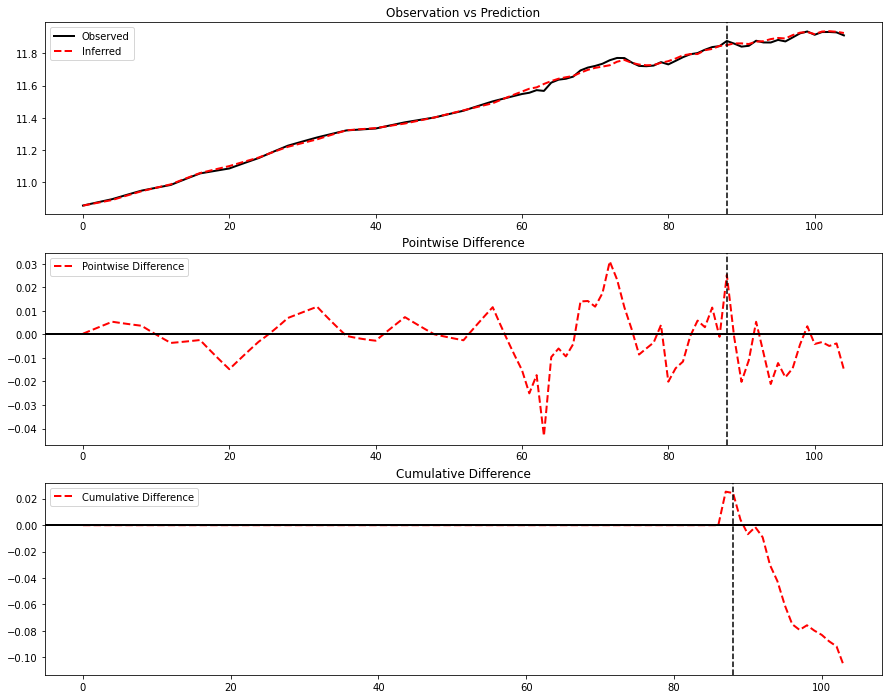

In [10]:
asynth.plot()

In [11]:
asynth = AugSynth(inference='UnitJackKnife')

In [12]:
asynth.run_analysis(panel_data, variation=2)

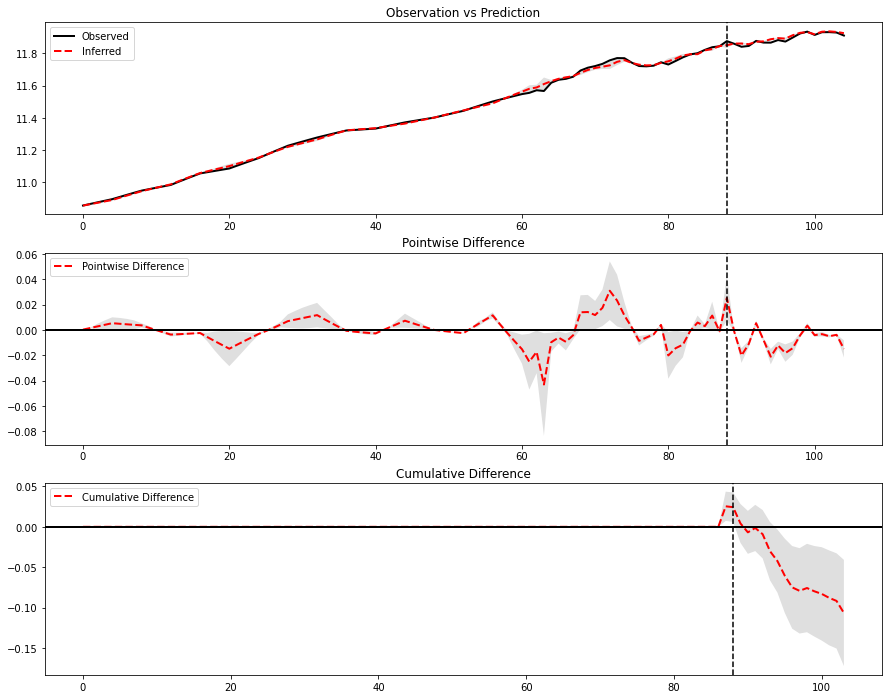

In [13]:
asynth.plot()

In [14]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import RidgeCV, Ridge

asynth = AugSynth(inference='UnitJackKnife', outcome_model=RidgeCV, alphas=[1e-3, 1e-2, 1e-1, 1])


In [15]:
asynth.run_analysis(panel_data, variation=2)


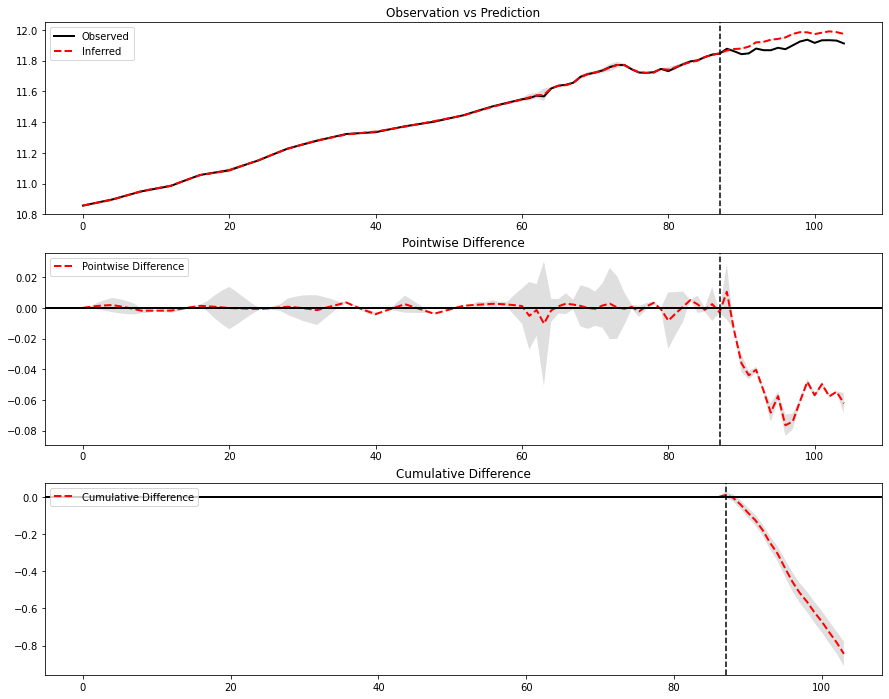

In [16]:
asynth.plot()

In [17]:
asynth = AugSynth(inference='UnitJackKnife', outcome_model=DecisionTreeRegressor)


In [18]:
asynth.run_analysis(panel_data, variation=2)


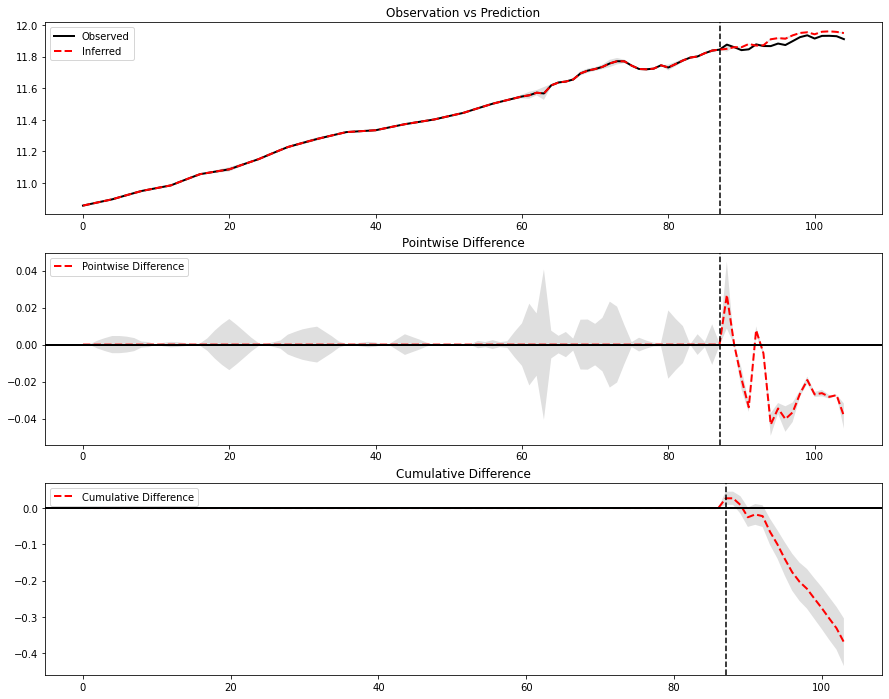

In [19]:
asynth.plot()